In [1]:
import os
import json
import math
import time
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import transforms

In [2]:
os.makedirs("./artifacts", exist_ok=True)
os.makedirs("./artifacts/figures", exist_ok=True)

In [3]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    """
    Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    """
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    """
    Отрисовка процесса обучения
    history имеет структуру:
        {
          "train_loss": [...], "val_loss": [...],
          "train_acc": [...],  "val_acc": [...]
        }
    """
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], "-o", label="train_loss")
    plt.plot(epochs, history["val_loss"], "-o", label="val_loss")
    
    best_val_loss_epoch = np.argmin(history["val_loss"]) + 1
    best_val_loss = np.min(history["val_loss"])
    plt.axvline(
        x=best_val_loss_epoch, color='green', linestyle='--', 
        label=f'Best val_loss: epoch {best_val_loss_epoch} ({best_val_loss:.4f})'
    )
    
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join("./artifacts/figures/", f"{title} (loss).png"))
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], "-o", label="train_acc")
    plt.plot(epochs, history["val_acc"], "-o", label="val_acc")
    
    best_val_acc_epoch = np.argmax(history["val_acc"]) + 1
    best_val_acc = np.max(history["val_acc"])
    plt.axvline(
        x=best_val_acc_epoch, color='green', linestyle='--', 
        label=f'Best val_acc: epoch {best_val_acc_epoch} ({best_val_acc:.4f})'
    )
    
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join("./artifacts/figures/", f"{title} (accuracy).png"))
    plt.show()


def set_seed(seed: int = 42) -> None:
    """
    Установка random state для всех генераторов
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def show_images(loader, n: int = 10) -> None:
    """
    Отображение n-картинок датасета
    """
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()


def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучение одной эпохи
    """
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float('nan'), float('nan')

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Оценка loss и accuracy
    """
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float('nan'), float('nan')

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    """
    Обучение модели - ПОЛНОСТЬЮ ОРИГИНАЛЬНАЯ
    """
    
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [4]:
RANDOM_STATE = 42  
set_seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)), 
])
transform

Compose(
    ToTensor()
    Normalize(mean=(0.5,), std=(0.5,))
)

In [6]:
train_full = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=False, download=True, transform=transform
)

class_names = train_full.classes
print(f"Classes ({len(class_names)}): {class_names}")
print(f"Train size: {len(train_full)}, Test size: {len(test_ds)}")

Classes (47): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
Train size: 112800, Test size: 18800


In [7]:
BATCH_SIZE = 256 if device.type == "cuda" else 64
NUM_WORKERS = 0 if os.name == "nt" else 2

val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(RANDOM_STATE)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([256, 1, 28, 28]) torch.float32
y_batch: torch.Size([256]) torch.int64


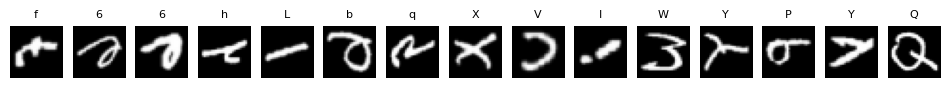

In [8]:
show_images(train_loader, n=15)

In [9]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
        num_classes: int = 47,
    ):
        super().__init__()
        
        act_layer = nn.ReLU
        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

epoch 01/20 | train loss=1.5644, acc=0.5582 | val loss=0.9838, acc=0.7106
epoch 02/20 | train loss=0.8374, acc=0.7427 | val loss=0.7371, acc=0.7762
epoch 03/20 | train loss=0.6782, acc=0.7858 | val loss=0.6591, acc=0.7964
epoch 04/20 | train loss=0.5938, acc=0.8068 | val loss=0.6098, acc=0.8048
epoch 05/20 | train loss=0.5411, acc=0.8209 | val loss=0.5680, acc=0.8220
epoch 06/20 | train loss=0.5036, acc=0.8315 | val loss=0.5495, acc=0.8176
epoch 07/20 | train loss=0.4754, acc=0.8382 | val loss=0.5401, acc=0.8204
epoch 08/20 | train loss=0.4520, acc=0.8440 | val loss=0.5138, acc=0.8333
epoch 09/20 | train loss=0.4317, acc=0.8498 | val loss=0.5325, acc=0.8267
epoch 10/20 | train loss=0.4133, acc=0.8560 | val loss=0.4944, acc=0.8363
epoch 11/20 | train loss=0.4012, acc=0.8586 | val loss=0.5328, acc=0.8248
epoch 12/20 | train loss=0.3865, acc=0.8622 | val loss=0.4963, acc=0.8353
epoch 13/20 | train loss=0.3732, acc=0.8658 | val loss=0.5173, acc=0.8309
epoch 14/20 | train loss=0.3613, acc=0

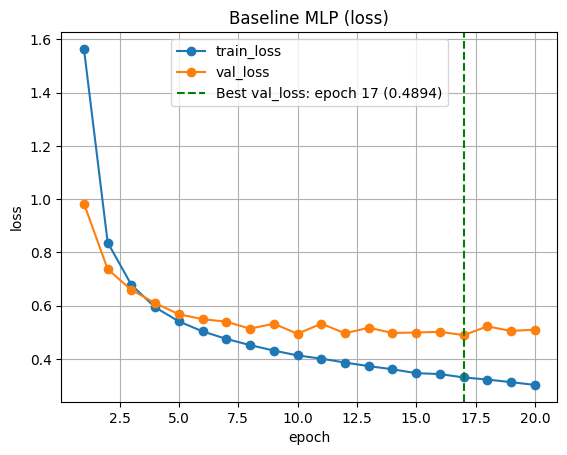

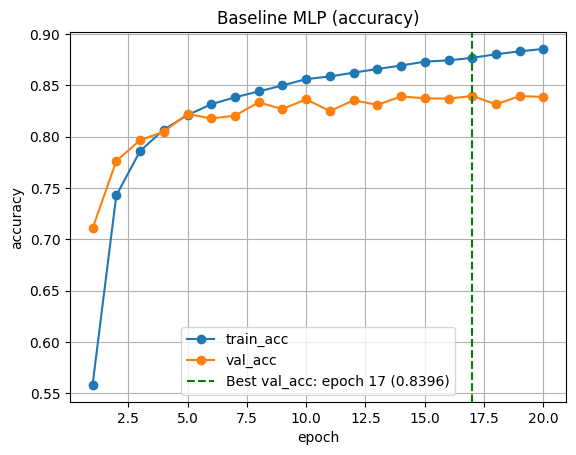

In [10]:
set_seed(42)

baseline = MLP(hidden_dims=(256, 128, 64)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
)
plot_history(history_baseline, title="Baseline MLP")

epoch 01/20 | train loss=2.1647, acc=0.3886 | val loss=1.0832, acc=0.6758
epoch 02/20 | train loss=1.3291, acc=0.6006 | val loss=0.8689, acc=0.7384
epoch 03/20 | train loss=1.1503, acc=0.6499 | val loss=0.7774, acc=0.7540
epoch 04/20 | train loss=1.0581, acc=0.6754 | val loss=0.7171, acc=0.7757
epoch 05/20 | train loss=1.0011, acc=0.6907 | val loss=0.6841, acc=0.7818
epoch 06/20 | train loss=0.9539, acc=0.7049 | val loss=0.6447, acc=0.7915
epoch 07/20 | train loss=0.9225, acc=0.7129 | val loss=0.6248, acc=0.7972
epoch 08/20 | train loss=0.8983, acc=0.7218 | val loss=0.6119, acc=0.8055
epoch 09/20 | train loss=0.8776, acc=0.7253 | val loss=0.6043, acc=0.8041
epoch 10/20 | train loss=0.8562, acc=0.7304 | val loss=0.5902, acc=0.8099
epoch 11/20 | train loss=0.8415, acc=0.7353 | val loss=0.5792, acc=0.8064
epoch 12/20 | train loss=0.8306, acc=0.7397 | val loss=0.5813, acc=0.8082
epoch 13/20 | train loss=0.8203, acc=0.7405 | val loss=0.5631, acc=0.8161
epoch 14/20 | train loss=0.8091, acc=0

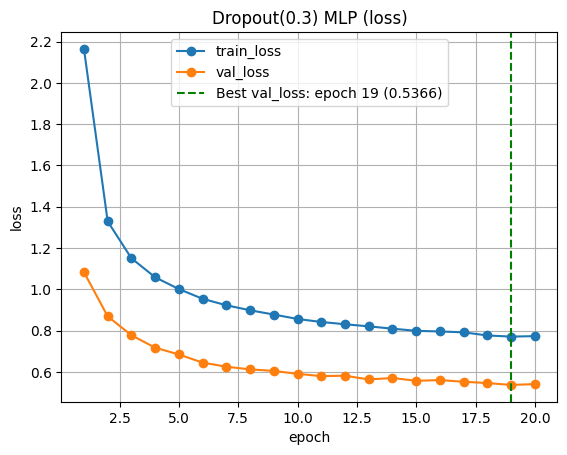

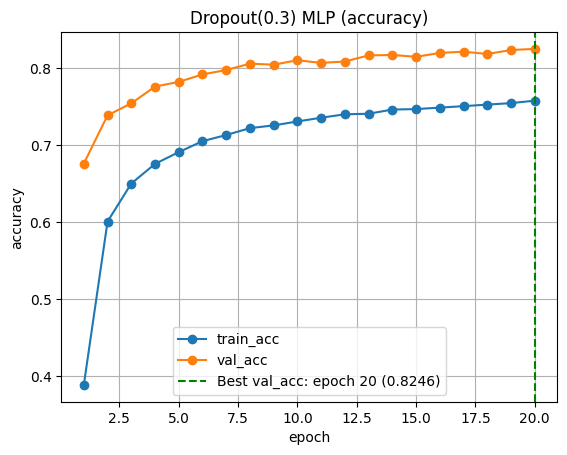

In [11]:
set_seed(42)

nn_dropout = MLP(hidden_dims=(256, 128, 64), dropout_p=0.3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(nn_dropout.parameters(), lr=1e-3)

history_nn_dropout = fit(
    nn_dropout, train_loader, val_loader,
    optimizer, criterion, device
)
plot_history(history_nn_dropout, title="Dropout(0.3) MLP")

epoch 01/20 | train loss=1.2427, acc=0.7065 | val loss=0.6509, acc=0.8076
epoch 02/20 | train loss=0.5443, acc=0.8235 | val loss=0.5453, acc=0.8168
epoch 03/20 | train loss=0.4472, acc=0.8480 | val loss=0.4716, acc=0.8428
epoch 04/20 | train loss=0.3982, acc=0.8607 | val loss=0.4653, acc=0.8461
epoch 05/20 | train loss=0.3645, acc=0.8699 | val loss=0.4584, acc=0.8416
epoch 06/20 | train loss=0.3359, acc=0.8784 | val loss=0.4603, acc=0.8441
epoch 07/20 | train loss=0.3144, acc=0.8843 | val loss=0.4565, acc=0.8436
epoch 08/20 | train loss=0.2978, acc=0.8890 | val loss=0.4476, acc=0.8548
epoch 09/20 | train loss=0.2787, acc=0.8947 | val loss=0.4687, acc=0.8467
epoch 10/20 | train loss=0.2664, acc=0.8987 | val loss=0.4617, acc=0.8501
epoch 11/20 | train loss=0.2540, acc=0.9025 | val loss=0.4648, acc=0.8477
epoch 12/20 | train loss=0.2435, acc=0.9062 | val loss=0.4614, acc=0.8472
epoch 13/20 | train loss=0.2325, acc=0.9084 | val loss=0.4816, acc=0.8472
epoch 14/20 | train loss=0.2237, acc=0

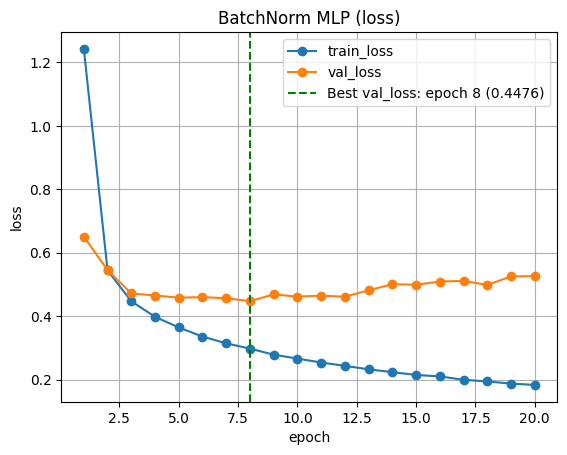

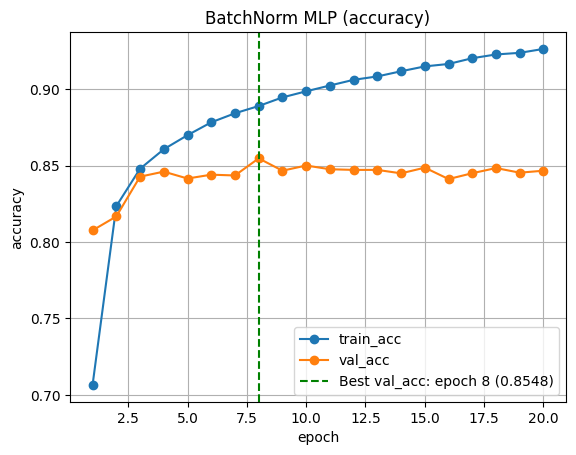

In [12]:
set_seed(42)

nn_batchnorm = MLP(hidden_dims=(256, 128, 64), use_batchnorm=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(nn_batchnorm.parameters(), lr=1e-3)

history_nn_batchnorm = fit(
    nn_batchnorm, train_loader, val_loader,
    optimizer, criterion, device
)

plot_history(history_nn_batchnorm, title="BatchNorm MLP")

In [13]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

epoch 01/20 | train loss=1.2427, acc=0.7065 | val loss=0.6509, acc=0.8076
epoch 02/20 | train loss=0.5443, acc=0.8235 | val loss=0.5453, acc=0.8168
epoch 03/20 | train loss=0.4472, acc=0.8480 | val loss=0.4716, acc=0.8428
epoch 04/20 | train loss=0.3982, acc=0.8607 | val loss=0.4653, acc=0.8461
epoch 05/20 | train loss=0.3645, acc=0.8699 | val loss=0.4584, acc=0.8416
epoch 06/20 | train loss=0.3359, acc=0.8784 | val loss=0.4603, acc=0.8441
epoch 07/20 | train loss=0.3144, acc=0.8843 | val loss=0.4565, acc=0.8436
epoch 08/20 | train loss=0.2978, acc=0.8890 | val loss=0.4476, acc=0.8548
epoch 09/20 | train loss=0.2787, acc=0.8947 | val loss=0.4687, acc=0.8467
epoch 10/20 | train loss=0.2664, acc=0.8987 | val loss=0.4617, acc=0.8501
epoch 11/20 | train loss=0.2540, acc=0.9025 | val loss=0.4648, acc=0.8477
epoch 12/20 | train loss=0.2435, acc=0.9062 | val loss=0.4614, acc=0.8472
EarlyStopping: остановка на эпохе 12. Лучший val_acc=0.8548


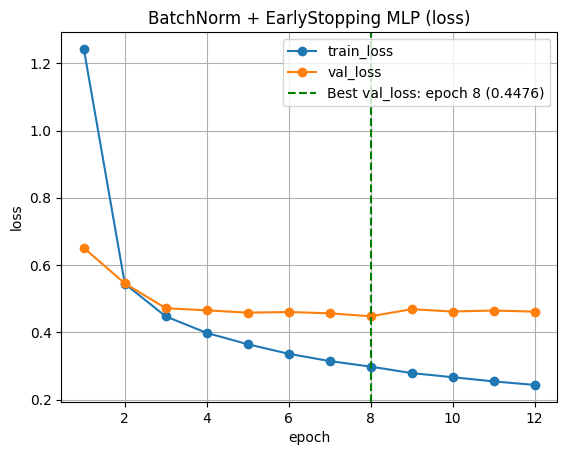

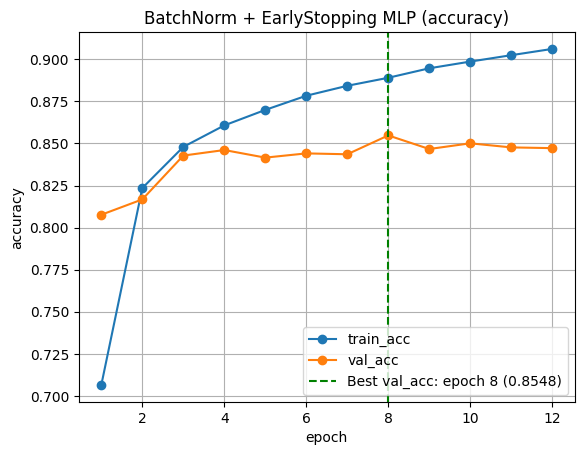

In [14]:
set_seed(42)

nn_best = MLP(hidden_dims=(256, 128, 64), use_batchnorm=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(nn_best.parameters(), lr=1e-3)
es = EarlyStopping(patience=4)

history_nn_best = fit(
    nn_best, train_loader, val_loader,
    optimizer, criterion, device, early_stopping=es
)

plot_history(history_nn_best, title="BatchNorm + EarlyStopping MLP")

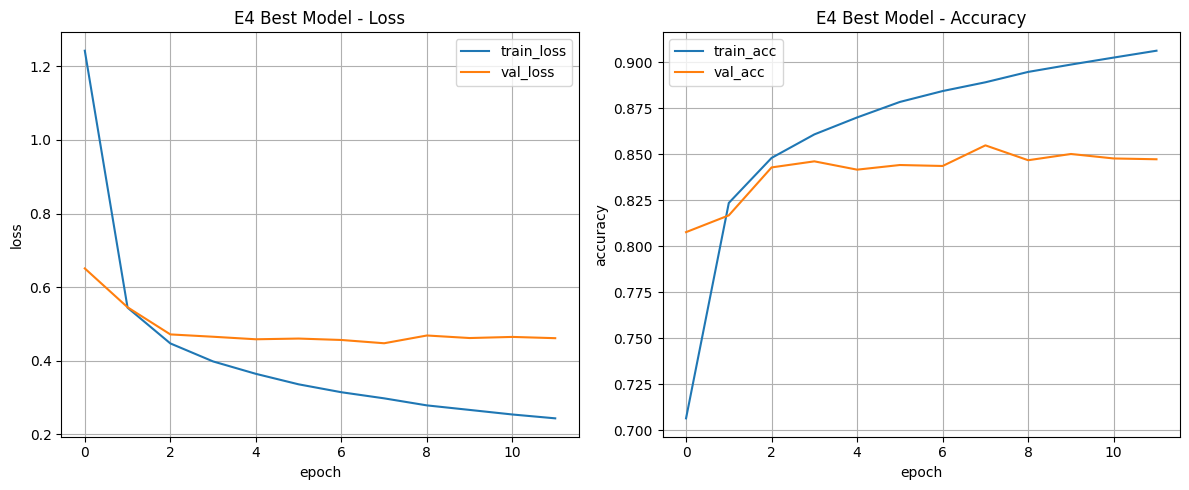

Финальная точность лучшей модели на тесте: 0.8491


In [15]:
torch.save(nn_best.state_dict(), "./artifacts/best_model.pt")

best_config = {
    "model": {
        "hidden_dims": [256, 128, 64],
        "dropout_p": 0.0,
        "use_batchnorm": True,
        "activation": "ReLU"
    },
    "training": {
        "optimizer": "Adam",
        "lr": 1e-3,
        "batch_size": BATCH_SIZE,
        "early_stopping_patience": 4,
        "seed": RANDOM_STATE
    },
    "dataset": {
        "name": "EMNIST",
        "train_size": len(train_ds),
        "val_size": len(val_ds),
        "test_size": len(test_ds),
        "num_classes": len(class_names)
    },
    "best_val_accuracy": max(history_nn_best["val_acc"]),
    "best_val_loss": min(history_nn_best["val_loss"])
}

with open("./artifacts/best_config.json", "w") as f:
    json.dump(best_config, f, indent=2)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_nn_best["train_loss"], label="train_loss")
plt.plot(history_nn_best["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("E4 Best Model - Loss")
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history_nn_best["train_acc"], label="train_acc")
plt.plot(history_nn_best["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("E4 Best Model - Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("./artifacts/figures/curves_best.png", dpi=150)
plt.show()

test_acc = evaluate(nn_best, test_loader, criterion, device)[1]
print(f"Финальная точность лучшей модели на тесте: {test_acc:.4f}")

In [16]:
torch.save(nn_best.state_dict(), "./artifacts/best_model.pt")

In [17]:
MODEL_CONFIG = {
    "hidden_dims": (256, 128, 64),
    "dropout_p": 0.0,       
    "use_batchnorm": True     
}

def make_model():
    return MLP(**MODEL_CONFIG).to(device)

def make_optimizer(model, kind, lr, weight_decay=0.0, momentum=0.9):
    kind = kind.lower().strip()
    if kind == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if kind == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {kind}")

def run_experiment(exp_id, optimizer_kind, lr, weight_decay=0.0, momentum=0.9, epochs=6):
    print(f"\n--- {exp_id} ---")
    set_seed(42)
    
    model = make_model()
    opt = make_optimizer(model, optimizer_kind, lr=lr, weight_decay=weight_decay, momentum=momentum)
    criterion = nn.CrossEntropyLoss()
    
    es = EarlyStopping(patience=4)
    hist = fit(model, train_loader, val_loader, opt, criterion, device, epochs=epochs)
    
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")
    best_val_loss = float(np.nanmin(hist["val_loss"])) if len(hist["val_loss"]) else float("nan")
    
    return {
        "exp_id": exp_id,
        "optimizer": optimizer_kind,
        "lr": lr,
        "weight_decay": weight_decay,
        "momentum": momentum if optimizer_kind.lower() == "sgd" else None,
        "epochs_ran": len(hist["val_acc"]),
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "history": hist,
    }


--- O1_LR_High ---
epoch 01/6 | train loss=1.0011, acc=0.6904 | val loss=0.8084, acc=0.7464
epoch 02/6 | train loss=0.6757, acc=0.7778 | val loss=0.6708, acc=0.7840
epoch 03/6 | train loss=0.5899, acc=0.8028 | val loss=0.6298, acc=0.8021
epoch 04/6 | train loss=0.5507, acc=0.8144 | val loss=0.5895, acc=0.8070
epoch 05/6 | train loss=0.5173, acc=0.8214 | val loss=0.5483, acc=0.8217
epoch 06/6 | train loss=0.4939, acc=0.8306 | val loss=0.5715, acc=0.8215


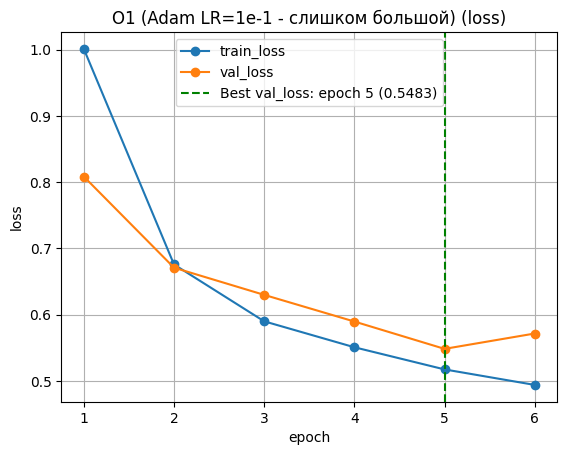

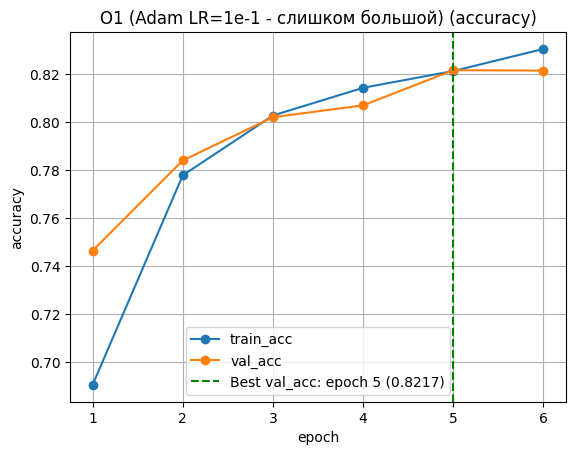

In [18]:
res_o1 = run_experiment(
    exp_id="O1_LR_High",
    optimizer_kind="adam",
    lr=1e-1,
    epochs=6
)
plot_history(res_o1["history"], title="O1 (Adam LR=1e-1 - слишком большой)")


--- O2_LR_Low ---
epoch 01/6 | train loss=3.6578, acc=0.1037 | val loss=3.4411, acc=0.1918
epoch 02/6 | train loss=3.3028, acc=0.2572 | val loss=3.1777, acc=0.3207
epoch 03/6 | train loss=3.0855, acc=0.3625 | val loss=2.9990, acc=0.4032
epoch 04/6 | train loss=2.9204, acc=0.4344 | val loss=2.8519, acc=0.4561
epoch 05/6 | train loss=2.7794, acc=0.4873 | val loss=2.7150, acc=0.5052
epoch 06/6 | train loss=2.6527, acc=0.5302 | val loss=2.5940, acc=0.5431


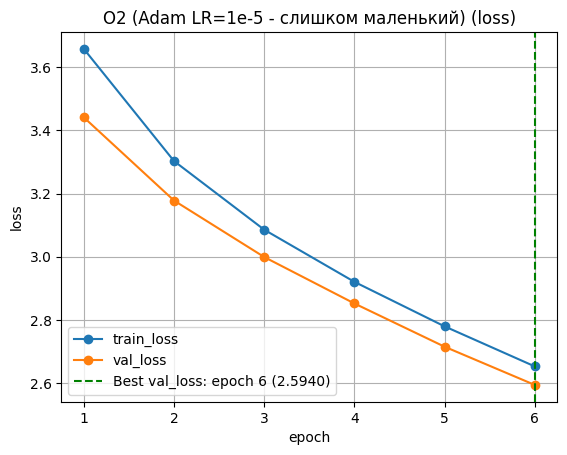

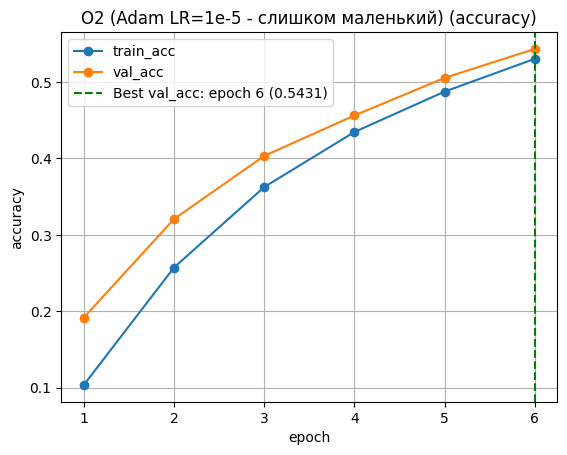

In [19]:
res_o2 = run_experiment(
    exp_id="O2_LR_Low",
    optimizer_kind="adam",
    lr=1e-5,
    epochs=6
)
plot_history(res_o2["history"], title="O2 (Adam LR=1e-5 - слишком маленький)")

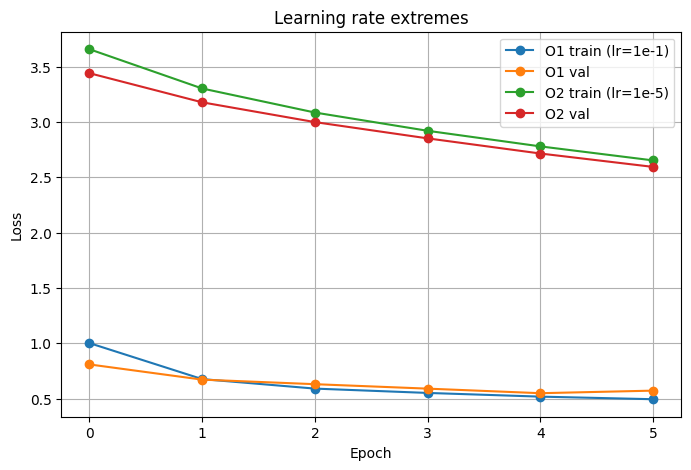

In [33]:
plt.figure(figsize=(8,5))

plt.plot(res_o1["history"]["train_loss"], "-o", label="O1 train (lr=1e-1)")
plt.plot(res_o1["history"]["val_loss"], "-o", label="O1 val")

plt.plot(res_o2["history"]["train_loss"], "-o", label="O2 train (lr=1e-5)")
plt.plot(res_o2["history"]["val_loss"], "-o", label="O2 val")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning rate extremes")
plt.legend()

plt.savefig("./artifacts/figures/curves_lr_extremes.png")
plt.grid(True)
plt.show()


--- O3_SGD ---
epoch 01/12 | train loss=1.4344, acc=0.6553 | val loss=0.7057, acc=0.7935
epoch 02/12 | train loss=0.6043, acc=0.8098 | val loss=0.5564, acc=0.8253
epoch 03/12 | train loss=0.4899, acc=0.8384 | val loss=0.5078, acc=0.8345
epoch 04/12 | train loss=0.4326, acc=0.8534 | val loss=0.4864, acc=0.8455
epoch 05/12 | train loss=0.3938, acc=0.8633 | val loss=0.4672, acc=0.8446
epoch 06/12 | train loss=0.3625, acc=0.8724 | val loss=0.4631, acc=0.8444
epoch 07/12 | train loss=0.3409, acc=0.8785 | val loss=0.4657, acc=0.8458
epoch 08/12 | train loss=0.3234, acc=0.8840 | val loss=0.4537, acc=0.8503
epoch 09/12 | train loss=0.3052, acc=0.8884 | val loss=0.4511, acc=0.8486
epoch 10/12 | train loss=0.2905, acc=0.8929 | val loss=0.4601, acc=0.8480
epoch 11/12 | train loss=0.2788, acc=0.8971 | val loss=0.4584, acc=0.8477
epoch 12/12 | train loss=0.2665, acc=0.9005 | val loss=0.4550, acc=0.8510


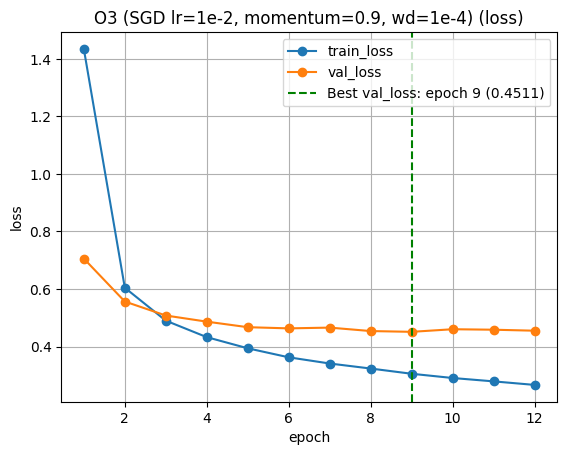

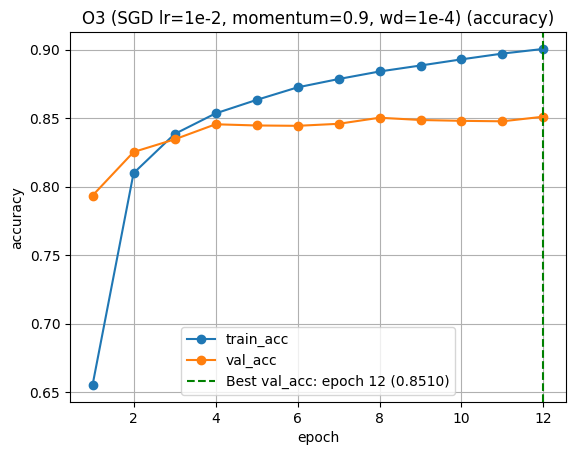

In [34]:
res_o3 = run_experiment(
    exp_id="O3_SGD",
    optimizer_kind="sgd",
    lr=1e-2,
    momentum=0.9,
    weight_decay=1e-4,
    epochs=12 
)
plot_history(res_o3["history"], title="O3 (SGD lr=1e-2, momentum=0.9, wd=1e-4)")

In [41]:
runs = [
    {
        "experiment_id": "E1",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "256-128-64",
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0,
        "weight_decay": 0,
        "epochs_trained": len(history_baseline["train_loss"]),
        "best_val_accuracy": max(history_baseline["val_acc"]),
        "best_val_loss": min(history_baseline["val_loss"])
    },

    {
        "experiment_id": "E2",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "256-128-64 dropout=0.3",
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0,
        "weight_decay": 0,
        "epochs_trained": len(history_nn_dropout["train_loss"]),
        "best_val_accuracy": max(history_nn_dropout["val_acc"]),
        "best_val_loss": min(history_nn_dropout["val_loss"])
    },

    {
        "experiment_id": "E3",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "256-128-64 batchnorm",
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0,
        "weight_decay": 0,
        "epochs_trained": len(history_nn_batchnorm["train_loss"]),
        "best_val_accuracy": max(history_nn_batchnorm["val_acc"]),
        "best_val_loss": min(history_nn_batchnorm["val_loss"])
    },

    {
        "experiment_id": "E4",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "256-128-64 batchnorm earlystop",
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0,
        "weight_decay": 0,
        "epochs_trained": len(history_nn_best["train_loss"]),
        "best_val_accuracy": max(history_nn_best["val_acc"]),
        "best_val_loss": min(history_nn_best["val_loss"])
    },

    {
        "experiment_id": "O1",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "same as E4",
        "optimizer": "Adam",
        "lr": 1e-1,
        "momentum": 0,
        "weight_decay": 0,
        "epochs_trained": len(res_o1["history"]["train_loss"]),
        "best_val_accuracy": max(res_o1["history"]["val_acc"]),
        "best_val_loss": min(res_o1["history"]["val_loss"])
    },

    {
        "experiment_id": "O2",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "same as E4",
        "optimizer": "Adam",
        "lr": 1e-5,
        "momentum": 0,
        "weight_decay": 0,
        "epochs_trained": len(res_o2["history"]["train_loss"]),
        "best_val_accuracy": max(res_o2["history"]["val_acc"]),
        "best_val_loss": min(res_o2["history"]["val_loss"])
    },

    {
        "experiment_id": "O3",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "same as E4",
        "optimizer": "SGD",
        "lr": 1e-2,
        "momentum": 0.9,
        "weight_decay": 1e-4,
        "epochs_trained": len(res_o3["history"]["train_loss"]),
        "best_val_accuracy": max(res_o3["history"]["val_acc"]),
        "best_val_loss": min(res_o3["history"]["val_loss"])
    }
]

runs_df = pd.DataFrame(runs)
runs_df.to_csv("./artifacts/runs.csv", index=False)
runs_df

,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,EMNIST,42,256-128-64,Adam,0.00100,0.0,0.0000,20,0.839583,0.489405
1,E2,EMNIST,42,256-128-64 dropout=0.3,Adam,0.00100,0.0,0.0000,20,0.824566,0.536569
2,E3,EMNIST,42,256-128-64 batchnorm,Adam,0.00100,0.0,0.0000,20,0.854774,0.447578
3,E4,EMNIST,42,256-128-64 batchnorm earlystop,Adam,0.00100,0.0,0.0000,12,0.854774,0.447578
4,O1,EMNIST,42,same as E4,Adam,0.10000,0.0,0.0000,6,0.821701,0.548273
5,O2,EMNIST,42,same as E4,Adam,0.00001,0.0,0.0000,6,0.543142,2.593985
6,O3,EMNIST,42,same as E4,SGD,0.01000,0.9,0.0001,12,0.851042,0.451061
